# GeoSlip2D profile slip inversion of synthetic data

This notebook demonstrates a complete 1D profile slip inversion workflow in GeoSlip2D using synthetic velocity data.

## Learning goals
- Build homogeneous Green's functions for a subduction interface.
- Project map-view velocity data onto a 1D profile.
- Solve a regularized slip inversion with configurable bounds and solver options.
- Interpret model fit, residuals, and recovered slip.

## Workflow overview
1. Configure inversion options and choose a synthetic dataset.
2. Load and project lon/lat velocity data to a profile.
3. Build and save/reload homogeneous Green's functions.
4. Solve the inversion and visualize fits and slip.

## Data format
Input files in the data directory use columns:

```text
lon, lat, Ve, Vn, Vu, Sige, Sign, Sigu
```

## Suggested run order
- Run all cells once from top to bottom.
- If you change dataset or inversion settings, rerun from Section 1 onward.
- If you change interface/Green's-function settings, rerun from Section 4 onward.

In [1]:
# import standard libraries and helper functions
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import geoslip2d as gs2d
from geoslip2d.inversion import (
    filter_profile_data,
    observations_from_projected_profile,
    save_inversion_result,
)

# Resolve project/data/output directories.
PROJECT_ROOT = Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = PROJECT_ROOT / "data"

print(f"Using PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Reading data from {DATA_DIR}")
print(f"Writing outputs to {OUTPUT_DIR}")

from geoslip2d.notebook_helpers import (
    make_synthetic_observations,
    patch_center_depths,
    patch_center_x,
    plot_inversion_results,
    plot_surface_velocities,
    run_pair_inversions,
    surface_velocity,
    uniform_backslip_above_depth,
)


Using PROJECT_ROOT = /home/jovyan/2026_Geodesy_TSC/notebooks/Day3
Reading data from /home/jovyan/2026_Geodesy_TSC/notebooks/Day3/data
Writing outputs to /home/jovyan/2026_Geodesy_TSC/notebooks/Day3/outputs


## 1. Choose dataset and inversion mode

Select a synthetic dataset and make sure the inversion sign convention matches it:

- `synthetic_data` -> `inversion_mode="forward_slip"`
- `synthetic_slowslip_data` -> `inversion_mode="slip_deficit"`

This section sets both choices so they stay synchronized.

In [38]:
# Choose which synthetic dataset to invert.
# - synthetic_data: interseismic style example
# - synthetic_slowslip_data: slowslip style example
# DATASET_NAME = "synthetic_data"  # "synthetic_data" or "synthetic_slowslip_data"
DATASET_NAME = "synthetic_slowslip_data"  # "synthetic_data" or "synthetic_slowslip_data"

if DATASET_NAME == "synthetic_data":
    data_filename = DATA_DIR / "synthetic_data.txt"
    inversion_mode = "slip_deficit"
elif DATASET_NAME == "synthetic_slowslip_data":
    data_filename = DATA_DIR / "synthetic_slowslip_data.txt"
    inversion_mode = "forward_slip"
else:
    raise ValueError("Unknown DATASET_NAME")


print(f"Dataset: {DATASET_NAME}")
print(f"Data file: {data_filename}")


# Baseline data type settings.
# Note: inversion settings are set in a later cell.
inversion_cfg = gs2d.SlipInversionConfig(
    data_has_vertical=True,
    save_results=True,
)






Dataset: synthetic_slowslip_data
Data file: /home/jovyan/2026_Geodesy_TSC/notebooks/Day3/data/synthetic_slowslip_data.txt


## 2. Load data and project to the profile

Load velocity data, filter invalid rows, project selected vectors to the profile, and create `ProfileObservations` for inversion.

In [39]:
# Load, filter, and project the data, 
# then extract the profile-parallel component of the projected displacements 
# as observations for inversion.


# Define the map/profile geometry used to project 2-D GNSS vectors onto a 1-D transect.
projection_cfg = gs2d.ProfileProjectionConfig(
    endpoints=(-120.0, 45.0, -116.0, 44.09), # Define the endpoints of the profile in (lon1, lat1, lon2, lat2).
    project_dist=20.0,  # Distance over which to project data points onto the profile.
    trench_llh=(-120.0, 45.0),  # Location of the trench in (lon, lat, height).
    horizontal_component="profile_parallel",  # Component of horizontal displacement to use.
)

data_raw = gs2d.load_profile_data(data_filename, data_has_vertical=inversion_cfg.data_has_vertical)
data, good_mask_original = filter_profile_data(data_raw, use_vertical=inversion_cfg.use_vertical)
profile = gs2d.project_data_to_profile(data, projection_cfg, use_vertical=inversion_cfg.use_vertical)
observations = observations_from_projected_profile(profile, use_vertical=inversion_cfg.use_vertical)

print(f"Number of original data rows: {data_raw['lon'].size}")
print(f"Number of retained data rows: {data['lon'].size}")
print(f"Number of data within profile swath: {observations.x_hor.size}")
print(f"Profile x range: {observations.x_hor.min():.2f} to {observations.x_hor.max():.2f} km")
print(f"Perpendicular distance range: {profile['perp_dist'][profile['in_profile']].min():.2f} to {profile['perp_dist'][profile['in_profile']].max():.2f} km")

Number of original data rows: 266
Number of retained data rows: 266
Number of data within profile swath: 43
Profile x range: 24.68 to 295.80 km
Perpendicular distance range: -19.86 to 11.47 km


## 3. Plot map-view data selection

Use this plot to verify that the profile swath and selected vectors are consistent with your intended transect.

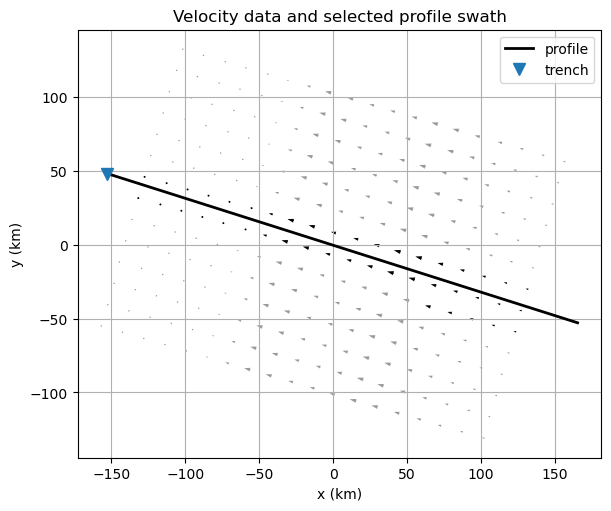

In [40]:


# Visualize the data and the profile swath to confirm that the projection 
# and selection of data points is as expected.
xy = profile["xy_gps"]
in_profile = profile["in_profile"]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax.quiver(
    xy[:, 0], xy[:, 1], data["Ve"], data["Vn"],
    angles="xy", scale_units="xy", scale=1, width=0.003, alpha=0.4,
)
ax.quiver(
    xy[in_profile, 0], xy[in_profile, 1],
    data["Ve"][in_profile], data["Vn"][in_profile],
    angles="xy", scale_units="xy", scale=1, width=0.004,
)
ax.plot(profile["xy_endpoints"][:, 0], profile["xy_endpoints"][:, 1], "k-", linewidth=2, label="profile")
ax.plot(profile["xy_trench"][0], profile["xy_trench"][1], "v", markersize=8, label="trench")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("Velocity data and selected profile swath")
ax.legend()
plt.show()

## 4. Build homogeneous Green's functions

Build the interface geometry and homogeneous Green's functions used by the inversion.

![Interface Geometry](./images/interface_geometry.png)

InterfaceGeometry(n_patch=52, x=[0, 251] km, z=[-0, 65.5] km)
Greens2D(source_type='homogeneous', n_obs=300, n_patch=52, has_vertical=True, units='displacement_per_unit_slip')


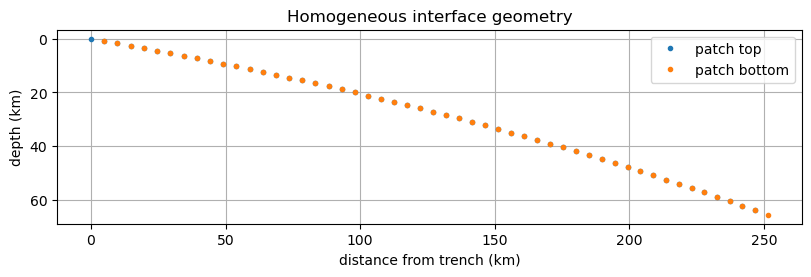

In [49]:
# Build the interface geometry and Green's functions for a homogeneous half-space model.
interface = gs2d.make_interface_geometry_legacy(
    faultdip_trench=10.0, # Dip of interface at the trench in degrees.
    x_trench=0.0, # Location of the trench in km from the profile start.
    x_bottom=250.0, # Location of the bottom of the fault in km from the profile start.
    faultdip_bottom=20.0, # Dip of interface at the bottom in degrees.
    z_bottom=65.0, # Depth of the bottom of the fault in km.
    patch_length=5.0, # Length of each fault patch in km.
)

# Define observation points along the profile at which to compute Green's functions.
# Note: these need not match the locations of the projected data points
# the start and end points should be chosen to encompass the projected data points, and the spacing should be fine enough to capture Green's function variability across the profile.
xobs = np.linspace(0.5, 500.0, 300)

# Build Green's functions 
greens = gs2d.build_greens(
    "homogeneous",
    interface,
    xobs,
    gs2d.HomogeneousConfig(length_override=5.0),
)

print(interface.summary())
print(greens.summary())

fig = gs2d.plot_interface(interface)
ax = fig.axes[0]
ax.set_title("Homogeneous interface geometry")
plt.show()

## 5. Save and reload Green's functions

Save Green's functions to disk and reload them to demonstrate reproducible I/O and downstream reuse.

In [50]:
greens_file = OUTPUT_DIR / "Greens_homogeneous_synthetic_profile.npz"
gs2d.save_greens(greens_file, greens)
greens = gs2d.load_greens(greens_file)

print(f"Saved/reloaded: {greens_file}")
print(greens.summary())

Saved/reloaded: /home/jovyan/2026_Geodesy_TSC/notebooks/Day3/outputs/Greens_homogeneous_synthetic_profile.npz
Greens2D(source_type='homogeneous', n_obs=300, n_patch=52, has_vertical=True, units='displacement_per_unit_slip')


## 6. Solve the slip inversion

Solve for profile slip using the configured regularization, solver, and inversion mode.

In [51]:
# Inversion settings.
# The dataset-specific inversion_mode is set below to keep them synchronized.
inversion_cfg = gs2d.SlipInversionConfig(
    alpha=1,  # smoothing parameter
    smoothing_order="second",  # "first", "second", or "none"
    use_vertical=True,
    data_has_vertical=True,
    inversion_mode="forward_slip",  # "forward_slip" or "slip_deficit"
    solver_type="nonnegative",  # "unbounded", "nonnegative", or "bounded"
    lower_bound=0.0,
    upper_bound=np.inf,
    save_results=True,
)

# Keep configuration consistent with dataset choice.
inversion_cfg.inversion_mode = inversion_mode


# Perform the profile slip inversion using GeoSlip2D.
result = gs2d.fit_profile_slip(observations, greens, inversion_cfg)

print("Profile slip inversion complete.")
print(f"  Number of horizontal data: {observations.x_hor.size}")
print(f"  Number of vertical data:   {observations.x_vert.size if observations.has_vertical else 0}")
print(f"  Number of model elements:  {greens.n_patch}")
print(f"  Inversion mode:            {inversion_cfg.inversion_mode}")
print(f"  Smoothing order:           {inversion_cfg.smoothing_order}")
print(f"  Solver type:               {inversion_cfg.solver_type}")
print(f"  Weighted RMS residual:     {result['wrms']:.3f}")
print(f"  Model roughness:           {result['roughness']:.3g}")

if inversion_cfg.save_results:
    save_inversion_result(inversion_cfg.results_filename, result)
    print(f"Saved result file: {inversion_cfg.results_filename}")

Profile slip inversion complete.
  Number of horizontal data: 43
  Number of vertical data:   43
  Number of model elements:  52
  Inversion mode:            forward_slip
  Smoothing order:           second
  Solver type:               nonnegative
  Weighted RMS residual:     0.577
  Model roughness:           2.35
Saved result file: profile_slip_inversion_results.mat


## 7. Plot fits and recovered slip

Plot horizontal/vertical fits, residuals, and the recovered slip distribution for interpretation and quality control.

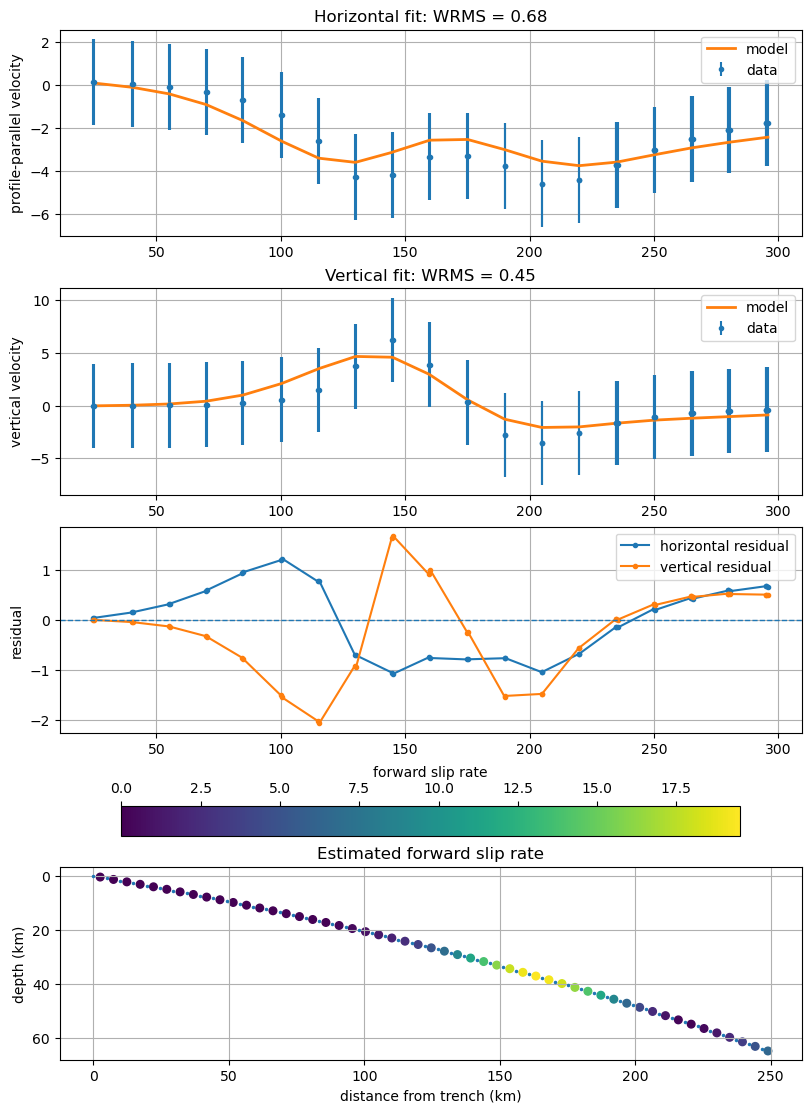

In [52]:
# Visualize the data fit, residuals, and estimated slip distribution.

# Sort the data by location for plotting.
order_h = np.argsort(observations.x_hor)
order_v = np.argsort(observations.x_vert) if observations.has_vertical else None
centers_x = greens.interface.centers[:, 0]
centers_z = greens.interface.centers[:, 1]

fig, axes = plt.subplots(4, 1, figsize=(8, 11), constrained_layout=True)

ax = axes[0]
ax.errorbar(observations.x_hor, observations.v_hor, yerr=2 * observations.sig_hor, fmt=".", label="data")
ax.plot(observations.x_hor[order_h], result["dhat_hor"][order_h], linewidth=2, label="model")
ax.set_ylabel(profile.get("horizontal_label", "horizontal velocity"))
ax.set_title(f"Horizontal fit: WRMS = {np.sqrt(np.mean((result['residual_hor'] / observations.sig_hor) ** 2)):.2f}")
ax.grid(True)
ax.legend()

ax = axes[1]
if observations.has_vertical:
    ax.errorbar(observations.x_vert, observations.v_vert, yerr=2 * observations.sig_vert, fmt=".", label="data")
    ax.plot(observations.x_vert[order_v], result["dhat_vert"][order_v], linewidth=2, label="model")
    ax.set_title(f"Vertical fit: WRMS = {np.sqrt(np.mean((result['residual_vert'] / observations.sig_vert) ** 2)):.2f}")
    ax.legend()
ax.set_ylabel("vertical velocity")
ax.grid(True)

ax = axes[2]
ax.plot(observations.x_hor[order_h], result["residual_hor"][order_h], ".-", label="horizontal residual")
if observations.has_vertical:
    ax.plot(observations.x_vert[order_v], result["residual_vert"][order_v], ".-", label="vertical residual")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_ylabel("residual")
ax.grid(True)
ax.legend()

ax = axes[3]
sc = ax.scatter(centers_x, centers_z, c=result["slip_hat"], s=30)
ax.plot(greens.interface.topx, greens.interface.topz, ".", markersize=3)
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()
ax.grid(True)
ax.set_xlabel("distance from trench (km)")
ax.set_ylabel("depth (km)")
ax.set_title(f"Estimated {result['model_label']}")
cbar = fig.colorbar(sc, ax=ax, orientation="horizontal", location="top")
cbar.set_label(result["model_label"])

fig.savefig(OUTPUT_DIR / f"{DATASET_NAME}_geoslip2d_inversion_summary.png", dpi=200)
plt.show()